In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

2025-05-26 12:12:42.873918: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-26 12:12:42.880468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748241762.888108    7320 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748241762.890459    7320 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748241762.896433    7320 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/UNET'

In [4]:
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images")

os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images'

In [17]:
# Load preprocessed training images and labels
train_input_dir_images = os.path.join(os.getcwd(),'gandhinagar_dataset/train/images')
train_input_dir_masks = os.path.join(os.getcwd(),'gandhinagar_dataset/train/masks')

# print(train_input_dir_images)
X_train = []
y_train = []

for i in range(int(len(os.listdir(train_input_dir_images)))):
    image_filename = f"{os.listdir(train_input_dir_images)[i]}"
    # print(image_filename)
    

    image_path = os.path.join(train_input_dir_images, image_filename)
    image = cv2.imread(image_path)
    X_train.append(image)

    label_filename = f"{os.listdir(train_input_dir_masks)[i]}"
    label_path = os.path.join(train_input_dir_masks, label_filename)
    label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
    y_train.append(label)

print(len(X_train))
print(len(y_train))

533
533


In [19]:
# Normalize pixel values
train_images = np.array(X_train) / 255.0
train_labels = np.array(y_train) / 255.0

# Main Code

In [1]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/UNET'

In [3]:
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True  # Optimize backend performance
torch.cuda.reset_peak_memory_stats()

In [5]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths
root_dir = '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images'
train_images_dir = os.path.join(root_dir, 'gandhinagar_dataset/train/images')
train_masks_dir = os.path.join(root_dir, 'gandhinagar_dataset/train/masks')
# val_images_dir = os.path.join(root_dir, 'Arial_validation_images/images')
# val_masks_dir = os.path.join(root_dir, 'Arial_validation_images/masks')

# Custom Dataset
class RooftopDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = sorted(os.listdir(image_dir))
        self.image_masksnames = sorted(os.listdir(mask_dir))

        self.transform = transform
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.image_masksnames[idx])
        
        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = mask.astype(np.float32) / 255.0
        
        if self.transform:
            image = self.transform(image)
            mask = transforms.ToTensor()(mask).unsqueeze(0)  # Ensure mask shape [1, H, W]
        
        return image, mask.squeeze(0)  # Ensure mask shape [H, W]

# Transformations
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((1024, 1024)),
    transforms.ToTensor()
])

# Load datasets
train_dataset = RooftopDataset(train_images_dir, train_masks_dir, transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)

# val_dataset = RooftopDataset(val_images_dir, val_masks_dir, transform)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

# U-Net Model
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU()
            )
        
        self.encoder = nn.ModuleList([
            conv_block(3, 16),
            conv_block(16, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256)
        ])
        
        self.pool = nn.MaxPool2d(2)
        
        self.upconv = nn.ModuleList([
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        ])
        
        self.decoder = nn.ModuleList([
            conv_block(256, 128),
            conv_block(128, 64),
            conv_block(64, 32),
            conv_block(32, 16)
        ])
        
        self.final_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        enc_outs = []
        for enc in self.encoder:
            x = enc(x)
            enc_outs.append(x)
            x = self.pool(x)
        
        for i in range(4):
            x = self.upconv[i](x)
            enc_out = enc_outs[-(i+2)]
            if x.shape[2:] != enc_out.shape[2:]:
                x = nn.functional.interpolate(x, size=enc_out.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, enc_out], dim=1)
            x = self.decoder[i](x)
        
        return torch.sigmoid(self.final_conv(x))

# Training Setup
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training Loop
def train(model, train_loader, epochs=50):

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)  # Ensure correct shape [B, 1, H, W]
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")
        losses.append(epoch_loss/len(train_loader))
    
    torch.save(model.state_dict(), "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/UNET/unet_rooftop_50_indian.pth")
    torch.save(model, "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/UNET/full_unet_rooftop_50_indian.pth")
    
    print("Model saved!")

    return losses 

loss = train(model, train_loader,epochs=50)
loss

Using device: cuda
Epoch 1/50, Loss: 0.6809
Epoch 2/50, Loss: 0.6074
Epoch 3/50, Loss: 0.4967
Epoch 4/50, Loss: 0.3869
Epoch 5/50, Loss: 0.2960
Epoch 6/50, Loss: 0.2513
Epoch 7/50, Loss: 0.2218
Epoch 8/50, Loss: 0.1929
Epoch 9/50, Loss: 0.1771
Epoch 10/50, Loss: 0.1663
Epoch 11/50, Loss: 0.1608
Epoch 12/50, Loss: 0.1580
Epoch 13/50, Loss: 0.1488
Epoch 14/50, Loss: 0.1456
Epoch 15/50, Loss: 0.1415
Epoch 16/50, Loss: 0.1395
Epoch 17/50, Loss: 0.1367
Epoch 18/50, Loss: 0.1347
Epoch 19/50, Loss: 0.1318
Epoch 20/50, Loss: 0.1287
Epoch 21/50, Loss: 0.1273
Epoch 22/50, Loss: 0.1269
Epoch 23/50, Loss: 0.1264
Epoch 24/50, Loss: 0.1255
Epoch 25/50, Loss: 0.1254
Epoch 26/50, Loss: 0.1220
Epoch 27/50, Loss: 0.1216
Epoch 28/50, Loss: 0.1230
Epoch 29/50, Loss: 0.1193
Epoch 30/50, Loss: 0.1210
Epoch 31/50, Loss: 0.1198
Epoch 32/50, Loss: 0.1171
Epoch 33/50, Loss: 0.1181
Epoch 34/50, Loss: 0.1157
Epoch 35/50, Loss: 0.1153
Epoch 36/50, Loss: 0.1150
Epoch 37/50, Loss: 0.1153
Epoch 38/50, Loss: 0.1114
Ep

[0.6808834759628072,
 0.6074273384669248,
 0.49667924379601197,
 0.3868625356870539,
 0.29603788651087704,
 0.25131457298994064,
 0.22181555015199325,
 0.19290712738738341,
 0.1771087909446043,
 0.16634366573656306,
 0.16079012392198339,
 0.15801549045478597,
 0.14884644396164837,
 0.14557933259536238,
 0.1415245719254017,
 0.13946925673414678,
 0.1367184302824385,
 0.13465419477399657,
 0.13182683552012725,
 0.12871539264040835,
 0.12732144423267422,
 0.12690627596834125,
 0.12640516350374503,
 0.12552485286312945,
 0.1253863152335672,
 0.12195009212283527,
 0.12157928176662501,
 0.12301899799529244,
 0.11929833779440206,
 0.12098878402920331,
 0.11978069254580666,
 0.11707181045237709,
 0.11805396790013593,
 0.11571418976082522,
 0.11533414156121366,
 0.1149778214885908,
 0.11533254472648397,
 0.11143008444239111,
 0.11130389549276408,
 0.11297931500217494,
 0.10863252619610113,
 0.11158551494864856,
 0.10854490780655075,
 0.10790215936653755,
 0.10853349373621099,
 0.107566763372982

In [7]:
len(loss)

50

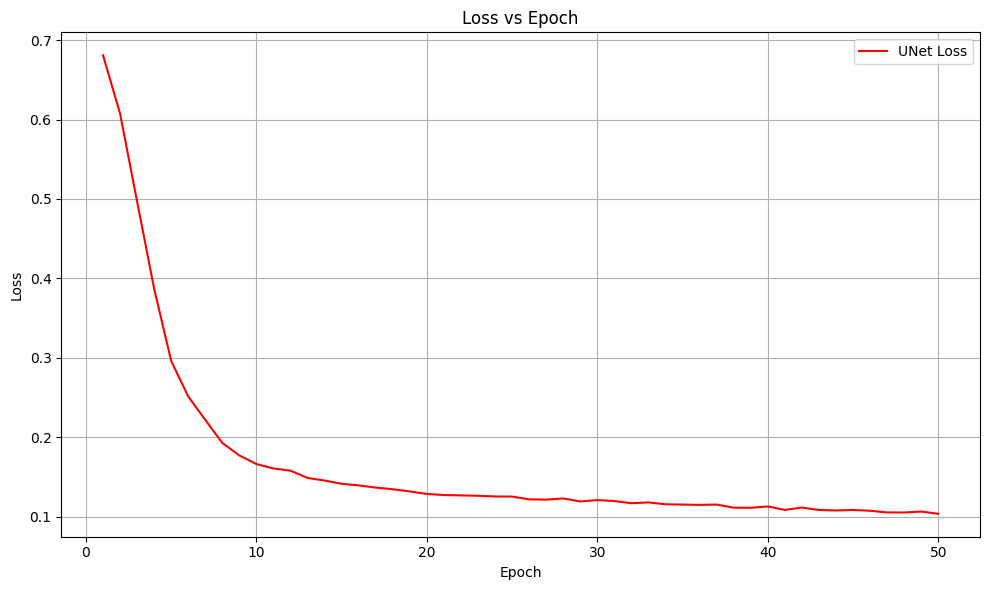

In [8]:
import matplotlib.pyplot as plt

unet_loss = loss
epochs = list(range(1,51))

plt.figure(figsize=(10, 6))
# plt.plot(epochs, maskrcnn_loss, label='Mask R-CNN Loss', color='green')
plt.plot(epochs, unet_loss, label='UNet Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig('/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/UNET/loss_vs_epoch_UNET_50_indian.png')
plt.tight_layout()
plt.show()

## Now Lets train the Unet model but this time we are going to use the weight of the US model.

In [2]:
import torch
import cv2
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

print(os.getcwd())

/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/UNET


In [3]:
from Unet_model import UNet

In [4]:
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True  # Optimize backend performance
torch.cuda.reset_peak_memory_stats()

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


root_dir = '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images'
train_images_dir = os.path.join(root_dir, 'gandhinagar_dataset/train/images')
train_masks_dir = os.path.join(root_dir, 'gandhinagar_dataset/train/masks')


class RooftopDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = sorted(os.listdir(image_dir))
        self.image_masksnames = sorted(os.listdir(mask_dir))

        self.transform = transform
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.image_masksnames[idx])
        
        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = mask.astype(np.float32) / 255.0
        
        if self.transform:
            image = self.transform(image)
            mask = transforms.ToTensor()(mask).unsqueeze(0)  # Ensure mask shape [1, H, W]
        
        return image, mask.squeeze(0)  # Ensure mask shape [H, W]


transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((1024, 1024)),
    transforms.ToTensor()
])

train_dataset = RooftopDataset(train_images_dir, train_masks_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)

model = UNet()

model.load_state_dict(torch.load("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/BaseLineModels/Unet_model/unet_rooftop_50.pth"))

model.to(device=device)

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)


def train(model, train_loader, epochs=50):

    losses = []

    for epoch in range(epochs):

        model.train()
        
        epoch_loss = 0
        
        for images, masks in train_loader:

            images, masks = images.to(device), masks.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            
            loss = criterion(outputs, masks)
            
            loss.backward()
            
            optimizer.step()
            
            epoch_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")
        
        losses.append(epoch_loss/len(train_loader))
    
    torch.save(model.state_dict(), "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/UNET/unet_rooftop_50_indian_usa.pth")
    
    torch.save(model, "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/UNET/full_unet_rooftop_50_indian_usa.pth")
    
    print("Model saved!")

    return losses 

loss = train(model, train_loader,epochs=50)
loss

Using device: cuda
Epoch 1/50, Loss: 0.1988
Epoch 2/50, Loss: 0.1246
Epoch 3/50, Loss: 0.1162
Epoch 4/50, Loss: 0.1104
Epoch 5/50, Loss: 0.1080
Epoch 6/50, Loss: 0.1057
Epoch 7/50, Loss: 0.1046
Epoch 8/50, Loss: 0.1046
Epoch 9/50, Loss: 0.1019
Epoch 10/50, Loss: 0.1004
Epoch 11/50, Loss: 0.0992
Epoch 12/50, Loss: 0.0985
Epoch 13/50, Loss: 0.0972
Epoch 14/50, Loss: 0.0960
Epoch 15/50, Loss: 0.0958
Epoch 16/50, Loss: 0.0946
Epoch 17/50, Loss: 0.0945
Epoch 18/50, Loss: 0.0928
Epoch 19/50, Loss: 0.0931
Epoch 20/50, Loss: 0.0915
Epoch 21/50, Loss: 0.0928
Epoch 22/50, Loss: 0.0967
Epoch 23/50, Loss: 0.0921
Epoch 24/50, Loss: 0.0892
Epoch 25/50, Loss: 0.0889
Epoch 26/50, Loss: 0.0874
Epoch 27/50, Loss: 0.0895
Epoch 28/50, Loss: 0.0871
Epoch 29/50, Loss: 0.0854
Epoch 30/50, Loss: 0.0855
Epoch 31/50, Loss: 0.0847
Epoch 32/50, Loss: 0.0848
Epoch 33/50, Loss: 0.0845
Epoch 34/50, Loss: 0.0823
Epoch 35/50, Loss: 0.0809
Epoch 36/50, Loss: 0.0814
Epoch 37/50, Loss: 0.0803
Epoch 38/50, Loss: 0.0789
Ep

[0.1988385985879337,
 0.12462117961224388,
 0.11620659644112867,
 0.11035706190501943,
 0.10796367683831383,
 0.10574763618847903,
 0.10461949578979436,
 0.10464904632638483,
 0.10189655751866453,
 0.10042107675005407,
 0.09918294496396009,
 0.09848490532706766,
 0.09718545087996651,
 0.09603021644494113,
 0.0957728753633359,
 0.09462339102345355,
 0.09446277074954089,
 0.09284929909250315,
 0.09311910346150398,
 0.09154224571059733,
 0.09282127877368647,
 0.09666602247778107,
 0.09206315984620768,
 0.08923182373537737,
 0.08887499943375587,
 0.08743564894094187,
 0.08945854972390567,
 0.08708451775943532,
 0.08543787787065786,
 0.0854674450614873,
 0.08474845088580076,
 0.08483750658000216,
 0.0845278817064622,
 0.0822551762137343,
 0.0809490286252078,
 0.08136227880330647,
 0.08031778004677857,
 0.07891086587572799,
 0.0789650757523144,
 0.07823288320180248,
 0.07749144119374893,
 0.07995768921340213,
 0.07573242792311836,
 0.0751786036964725,
 0.0733964194488876,
 0.0736301286036477

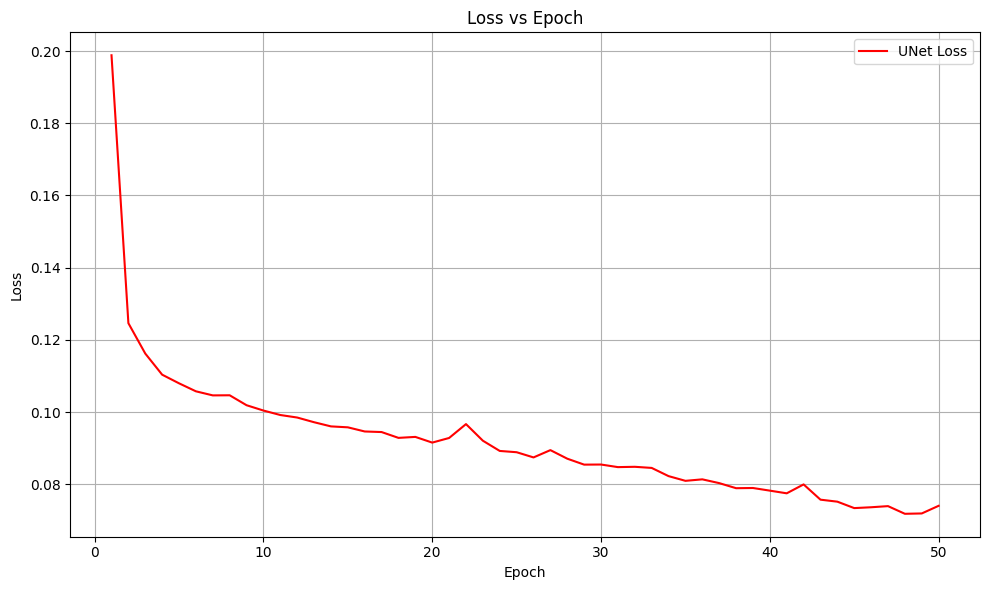

In [6]:
import matplotlib.pyplot as plt

unet_loss = loss
epochs = list(range(1,51))

plt.figure(figsize=(10, 6))
# plt.plot(epochs, maskrcnn_loss, label='Mask R-CNN Loss', color='green')
plt.plot(epochs, unet_loss, label='UNet Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig('/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/UNET/loss_vs_epoch_UNET_50_indian_usa.png')
plt.tight_layout()
plt.show()